# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from pmdarima import auto_arima
import joblib
import os

# Dataset

In [2]:
train = pd.read_csv('data/raw/train_aWnotu.csv')
test  = pd.read_csv('data/raw/test.csv')

print('Train shape:', train.shape)
print('Test shape :', test.shape)

Train shape: (48120, 4)
Test shape : (11808, 3)


In [3]:
train.head()

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [4]:
print('Data types:')
print(train.dtypes)
print()
print('Missing values:')
print(train.isnull().sum())

Data types:
DateTime    object
Junction     int64
Vehicles     int64
ID           int64
dtype: object

Missing values:
DateTime    0
Junction    0
Vehicles    0
ID          0
dtype: int64


In [5]:
train.describe()

,Junction,Vehicles,ID
count,48120.000000,48120.000000,4.812000e+04
mean,2.180549,22.791334,2.016330e+10
std,0.966955,20.750063,5.944854e+06
min,1.000000,1.000000,2.015110e+10
25%,1.000000,9.000000,2.016042e+10
50%,2.000000,15.000000,2.016093e+10
75%,3.000000,29.000000,2.017023e+10
max,4.000000,180.000000,2.017063e+10


# Data Cleaning

In [6]:
train['DateTime'] = pd.to_datetime(train['DateTime'])
test['DateTime']  = pd.to_datetime(test['DateTime'])

train = train.sort_values(['Junction', 'DateTime']).reset_index(drop=True)
test  = test.sort_values(['Junction', 'DateTime']).reset_index(drop=True)

print('Date range in train:', train['DateTime'].min(), 'to', train['DateTime'].max())
print('Date range in test :', test['DateTime'].min(),  'to', test['DateTime'].max())

Date range in train: 2015-11-01 00:00:00 to 2017-06-30 23:00:00
Date range in test : 2017-07-01 00:00:00 to 2017-10-31 23:00:00


In [7]:
print('Records per junction:')
print(train['Junction'].value_counts().sort_index())
print()
print('Average vehicles per junction:')
print(train.groupby('Junction')['Vehicles'].mean().round(1))

Records per junction:
Junction
1    14592
2    14592
3    14592
4     4344
Name: count, dtype: int64

Average vehicles per junction:
Junction
1    45.1
2    14.3
3    13.7
4     7.3
Name: Vehicles, dtype: float64


# EDA

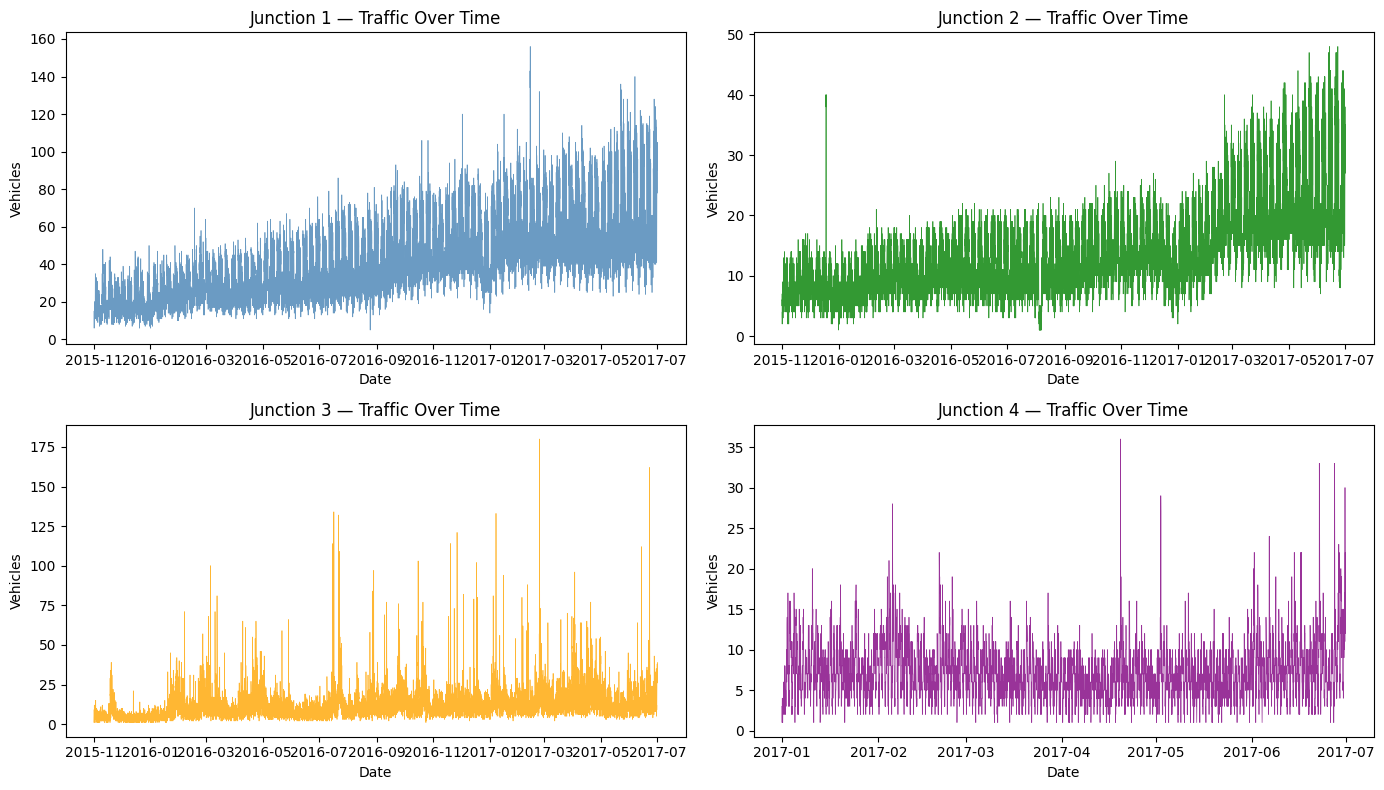

In [8]:
plt.figure(figsize=(14, 8))

colors = {1: 'steelblue', 2: 'green', 3: 'orange', 4: 'purple'}

for i, junction in enumerate([1, 2, 3, 4], 1):
    plt.subplot(2, 2, i)
    data = train[train['Junction'] == junction]
    plt.plot(data['DateTime'], data['Vehicles'],
             color=colors[junction], linewidth=0.5, alpha=0.8)
    plt.title(f'Junction {junction} — Traffic Over Time')
    plt.xlabel('Date')
    plt.ylabel('Vehicles')

plt.tight_layout()
plt.savefig('outputs/Traffic Over Time.png',dpi=300)
plt.show()

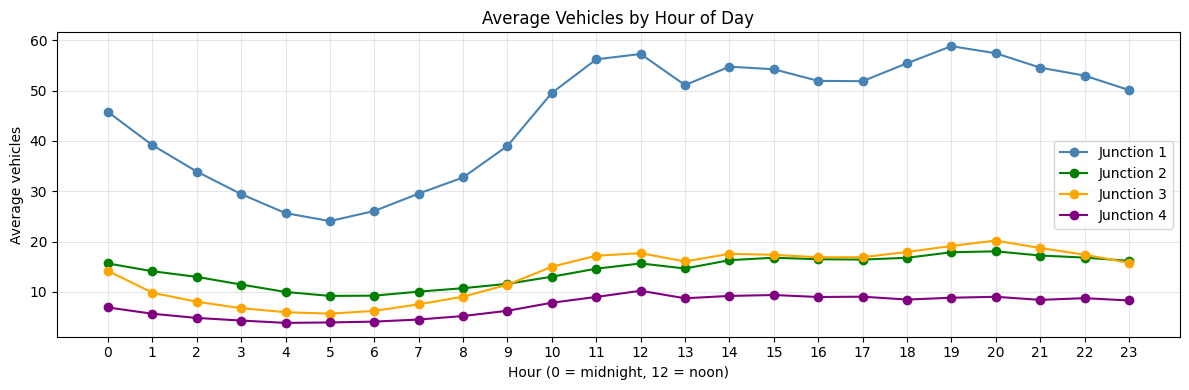

In [9]:
train['hour'] = train['DateTime'].dt.hour

plt.figure(figsize=(12, 4))

for junction in [1, 2, 3, 4]:
    data   = train[train['Junction'] == junction]
    hourly = data.groupby('hour')['Vehicles'].mean()
    plt.plot(hourly, marker='o', label=f'Junction {junction}', color=colors[junction])

plt.title('Average Vehicles by Hour of Day')
plt.xlabel('Hour (0 = midnight, 12 = noon)')
plt.ylabel('Average vehicles')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/Average Vehicles by Hour.png',dpi=300)
plt.show()

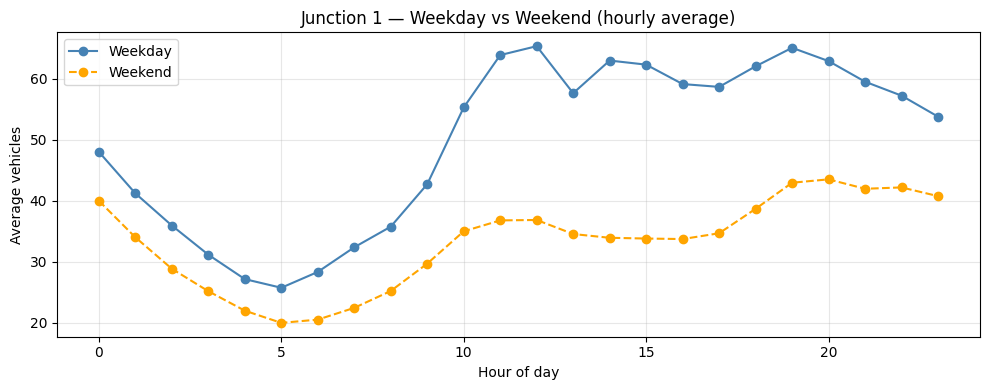

In [10]:
train['day_of_week'] = train['DateTime'].dt.dayofweek  # 0=Monday, 6=Sunday
train['is_weekend']  = (train['day_of_week'] >= 5).astype(int)

plt.figure(figsize=(10, 4))

# Average by hour for weekday vs weekend (Junction 1 as example)
j1 = train[train['Junction'] == 1]
weekday = j1[j1['is_weekend'] == 0].groupby('hour')['Vehicles'].mean()
weekend = j1[j1['is_weekend'] == 1].groupby('hour')['Vehicles'].mean()

plt.plot(weekday, label='Weekday', color='steelblue', marker='o')
plt.plot(weekend, label='Weekend', color='orange',   marker='o', linestyle='--')
plt.title('Junction 1 — Weekday vs Weekend (hourly average)')
plt.xlabel('Hour of day')
plt.ylabel('Average vehicles')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/Weekday vs Weekend.png',dpi=300)
plt.show()

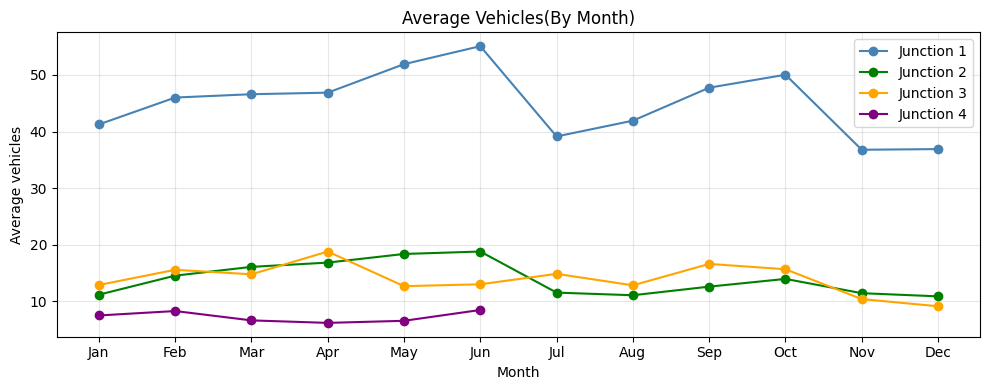

In [11]:
train['month'] = train['DateTime'].dt.month

plt.figure(figsize=(10, 4))

for junction in [1, 2, 3, 4]:
    data    = train[train['Junction'] == junction]
    monthly = data.groupby('month')['Vehicles'].mean()
    plt.plot(monthly, marker='o', label=f'Junction {junction}', color=colors[junction])

plt.title('Average Vehicles(By Month)')
plt.xlabel('Month')
plt.ylabel('Average vehicles')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/Average by Month.png',dpi=300)
plt.show()

# Feature Engg.

In [12]:
def add_features(df):
    df = df.copy()

    df['hour']        = df['DateTime'].dt.hour
    df['day']         = df['DateTime'].dt.day
    df['month']       = df['DateTime'].dt.month
    df['year']        = df['DateTime'].dt.year
    df['day_of_week'] = df['DateTime'].dt.dayofweek

    # Weekend flag
    df['is_weekend'] = 0
    df.loc[df['day_of_week'] >= 5, 'is_weekend'] = 1

    # Rush hour flag
    peak_hours = [7, 8, 9, 17, 18, 19]
    df['is_peak'] = 0
    df.loc[df['hour'].isin(peak_hours), 'is_peak'] = 1

    return df


train = add_features(train)
test  = add_features(test)

print('New columns added:')
print(train.columns.tolist())
print()
train.head()

New columns added:
['DateTime', 'Junction', 'Vehicles', 'ID', 'hour', 'day_of_week', 'is_weekend', 'month', 'day', 'year', 'is_peak']



,DateTime,Junction,Vehicles,ID,hour,day_of_week,is_weekend,month,day,year,is_peak
0,2015-11-01 00:00:00,1,15,20151101001,0,6,1,11,1,2015,0
1,2015-11-01 01:00:00,1,13,20151101011,1,6,1,11,1,2015,0
2,2015-11-01 02:00:00,1,10,20151101021,2,6,1,11,1,2015,0
3,2015-11-01 03:00:00,1,7,20151101031,3,6,1,11,1,2015,0
4,2015-11-01 04:00:00,1,9,20151101041,4,6,1,11,1,2015,0


# XGBoost 

In [13]:
FEATURES = ['hour', 'day', 'month', 'year', 'day_of_week',
            'is_weekend', 'is_peak', 'Junction']
TARGET   = 'Vehicles'

cutoff_date = train['DateTime'].max() - pd.Timedelta(weeks=4)

train_data = train[train['DateTime'] <= cutoff_date]
val_data   = train[train['DateTime'] >  cutoff_date]

print('Training rows  :', len(train_data))
print('Validation rows:', len(val_data))
print('Cutoff date    :', cutoff_date.date())

Training rows  : 45432
Validation rows: 2688
Cutoff date    : 2017-06-02


In [14]:
X_train = train_data[FEATURES]
y_train = train_data[TARGET]

X_val   = val_data[FEATURES]
y_val   = val_data[TARGET]

xgb_model = XGBRegressor(
    n_estimators  = 500,
    learning_rate = 0.05,
    max_depth     = 5,
    random_state  = 42
)

xgb_model.fit(X_train, y_train)

print('Training complete!')

Training complete!


In [15]:
xgb_val_preds = xgb_model.predict(X_val)
xgb_val_preds = np.maximum(xgb_val_preds, 0)   # no negative values

rmse = np.sqrt(mean_squared_error(y_val, xgb_val_preds))
print('XGBoost Validation RMSE:', round(rmse, 2))
print('(Lower is better)')

XGBoost Validation RMSE: 6.56
(Lower is better)


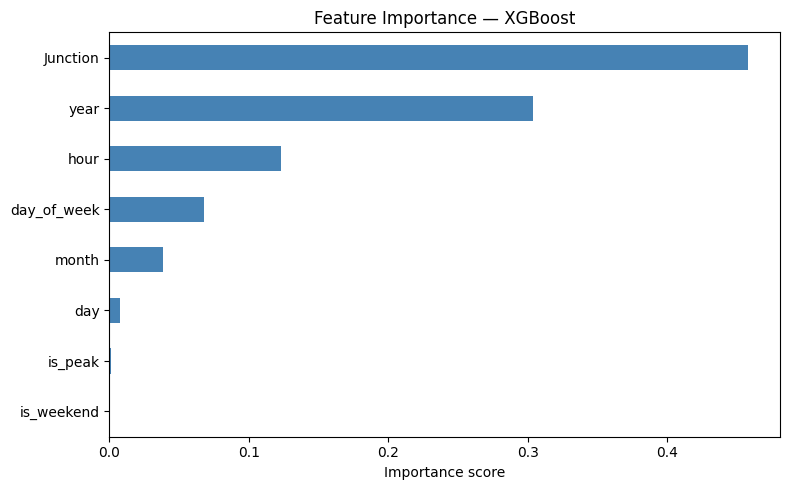

In [16]:
importance = pd.Series(xgb_model.feature_importances_, index=FEATURES)
importance = importance.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importance.plot(kind='barh', color='steelblue')
plt.title('Feature Importance — XGBoost')
plt.xlabel('Importance score')
plt.tight_layout()
plt.savefig('outputs/XGB Feature Importance.png',dpi=300)
plt.show()

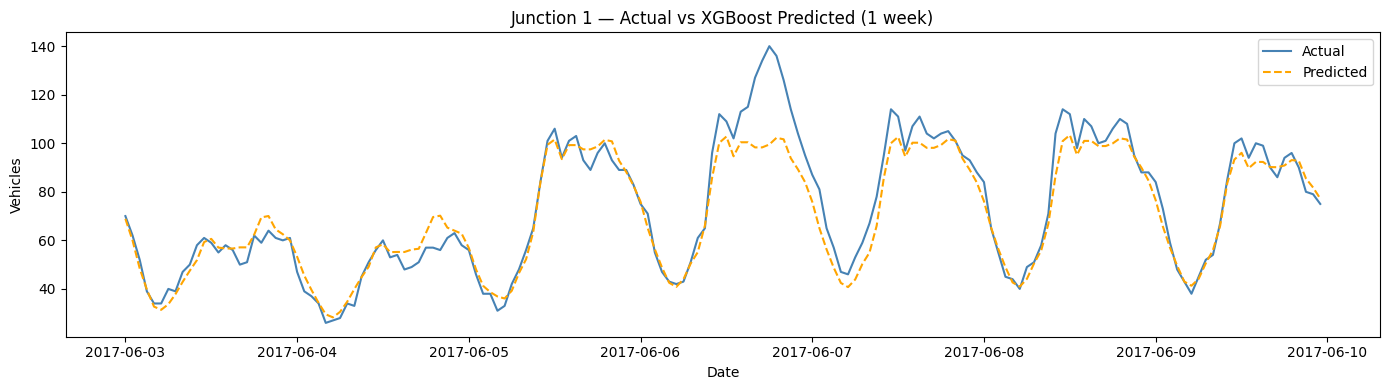

In [17]:
j1_val = val_data[val_data['Junction'] == 1].head(24 * 7)  # one week
j1_idx = j1_val.index
j1_pred = xgb_val_preds[val_data.index.get_indexer(j1_idx)]

plt.figure(figsize=(14, 4))
plt.plot(j1_val['DateTime'].values, j1_val['Vehicles'].values,
         label='Actual',    color='steelblue', linewidth=1.5)
plt.plot(j1_val['DateTime'].values, j1_pred,
         label='Predicted', color='orange',    linewidth=1.5, linestyle='--')
plt.title('Junction 1 — Actual vs XGBoost Predicted (1 week)')
plt.xlabel('Date')
plt.ylabel('Vehicles')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/Actual vs XGB Prediction.png',dpi=300)
plt.show()

# SARIMA Model

In [18]:
os.makedirs('sarima_models', exist_ok=True)

sarima_models = {}

for junction in [1, 2, 3, 4]:
    model_path = f'sarima_models/junction_{junction}.pkl'

    
    if os.path.exists(model_path):
        sarima_models[junction] = joblib.load(model_path)
        print(f'Junction {junction}: loaded from file')
        continue

    print(f'Junction {junction}: training...')

    jdata  = train[train['Junction'] == junction]
    series = jdata.set_index('DateTime')['Vehicles']

    model = auto_arima(
        series,
        seasonal          = True,
        m                 = 7,    # weekly pattern
        max_p             = 2,    # limit AR terms
        max_q             = 2,    # limit MA terms
        max_P             = 1,    # limit seasonal AR terms
        max_Q             = 1,    # limit seasonal MA terms
        stepwise          = True,
        suppress_warnings = True,
        error_action      = 'ignore'
    )

    print(f'  Order: {model.order}, Seasonal: {model.seasonal_order}')

    sarima_models[junction] = model
    joblib.dump(model, model_path)
    print(f'  Saved to {model_path}')

print('All SARIMA models ready!')

Junction 1: loaded from file
Junction 2: loaded from file
Junction 3: loaded from file
Junction 4: loaded from file
All SARIMA models ready!


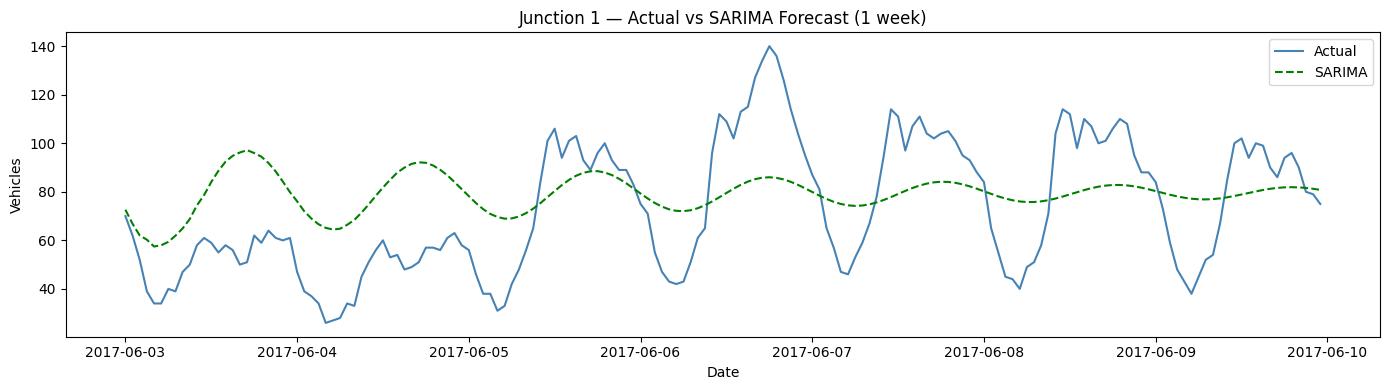

In [19]:
n_periods = 24 * 7   # one week of hours

forecast  = sarima_models[1].predict(n_periods=n_periods)
forecast  = np.maximum(forecast, 0)


actual = val_data[val_data['Junction'] == 1]['Vehicles'].values[:n_periods]
dates  = val_data[val_data['Junction'] == 1]['DateTime'].values[:n_periods]

plt.figure(figsize=(14, 4))
plt.plot(dates,    actual,   label='Actual',   color='steelblue', linewidth=1.5)
plt.plot(dates,    forecast, label='SARIMA',   color='green',     linewidth=1.5, linestyle='--')
plt.title('Junction 1 — Actual vs SARIMA Forecast (1 week)')
plt.xlabel('Date')
plt.ylabel('Vehicles')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/Actual vs SARIMA Forecast.png',dpi=300)
plt.show()

# Blend Models (XGB+SARIMA)

In [20]:
X_val_clean = val_data[FEATURES].fillna(0)   
y_val_clean  = val_data['Vehicles'].values

xgb_val_preds = xgb_model.predict(X_val_clean)
xgb_val_preds = np.maximum(xgb_val_preds, 0)

sarima_val_preds_list = []

for junction in [1, 2, 3, 4]:
    jval  = val_data[val_data['Junction'] == junction]
    n     = len(jval)
    preds = sarima_models[junction].predict(n_periods=n)
    preds = np.array(preds, dtype=float)       
    preds = np.maximum(preds, 0)               
    sarima_val_preds_list.append(pd.Series(preds, index=jval.index))

sarima_val_preds = pd.concat(sarima_val_preds_list).sort_index()
sarima_val_preds = sarima_val_preds.fillna(sarima_val_preds.mean())  
sarima_val_preds = sarima_val_preds.values


n = min(len(xgb_val_preds), len(sarima_val_preds), len(y_val_clean))

xgb_val_preds    = xgb_val_preds[:n]
sarima_val_preds = sarima_val_preds[:n]
y_val_clean      = y_val_clean[:n]


blended_val  = 0.6 * xgb_val_preds + 0.4 * sarima_val_preds
blended_rmse = np.sqrt(mean_squared_error(y_val_clean, blended_val))

print()
print('XGBoost RMSE :', round(np.sqrt(mean_squared_error(y_val_clean, xgb_val_preds)), 2))
print('SARIMA RMSE  :', round(np.sqrt(mean_squared_error(y_val_clean, sarima_val_preds)), 2))
print('Blended RMSE :', round(blended_rmse, 2))


XGBoost RMSE : 6.56
SARIMA RMSE  : 16.8
Blended RMSE : 9.13


# Predict and Save

In [21]:
X_test        = test[FEATURES]
xgb_test_pred = xgb_model.predict(X_test)
xgb_test_pred = np.maximum(xgb_test_pred, 0)

sarima_test_list = []

for junction in [1, 2, 3, 4]:
    jtest = test[test['Junction'] == junction]
    n     = len(jtest)

    preds = sarima_models[junction].predict(n_periods=n)
    preds = np.maximum(preds, 0)

    sarima_test_list.append(pd.Series(preds, index=jtest.index))

sarima_test_pred = pd.concat(sarima_test_list).sort_index().values

# Blend
final_preds = 0.6 * xgb_test_pred + 0.4 * sarima_test_pred
final_preds = np.round(final_preds).astype(int)

print('Predictions done!')
print('Min:', final_preds.min(), '| Max:', final_preds.max(),
      '| Mean:', round(final_preds.mean(), 1))

Predictions done!
Min: -9223372036854775808 | Max: -9223372036854775808 | Mean: -9.223372036854776e+18


In [22]:
submission = pd.DataFrame({
    'ID'      : test['ID'],
    'Vehicles': final_preds
})

os.makedirs('../outputs/submissions', exist_ok=True)
submission.to_csv('../outputs/submissions/submission.csv', index=False)

print('Submission saved!')
submission.head(10)

Submission saved!


,ID,Vehicles
0,20170701001,-9223372036854775808
1,20170701011,-9223372036854775808
2,20170701021,-9223372036854775808
3,20170701031,-9223372036854775808
4,20170701041,-9223372036854775808
5,20170701051,-9223372036854775808
6,20170701061,-9223372036854775808
7,20170701071,-9223372036854775808
8,20170701081,-9223372036854775808
9,20170701091,-9223372036854775808


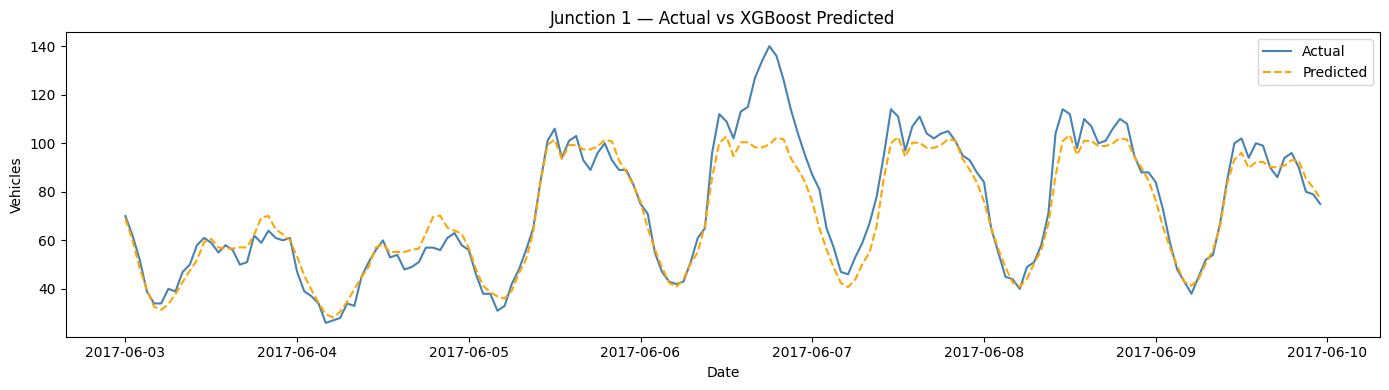

In [23]:
j1_val = val_data[val_data['Junction'] == 1].copy()
j1_val = j1_val.head(24 * 7)  # first 7 days

# Fill any missing feature values with 0
j1_features = j1_val[FEATURES].fillna(0)

j1_pred = xgb_model.predict(j1_features)
j1_pred = np.maximum(j1_pred, 0)

plt.figure(figsize=(14, 4))
plt.plot(j1_val['DateTime'].values, j1_val['Vehicles'].values,
         label='Actual',    color='steelblue', linewidth=1.5)
plt.plot(j1_val['DateTime'].values, j1_pred,
         label='Predicted', color='orange',    linewidth=1.5, linestyle='--')
plt.title('Junction 1 — Actual vs XGBoost Predicted')
plt.xlabel('Date')
plt.ylabel('Vehicles')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/Final Check.png',dpi=300)
plt.show()

In [24]:
import os

os.makedirs('submissions', exist_ok=True)

submission = pd.DataFrame({
    'ID'      : test['ID'],
    'Vehicles': final_preds
})

submission.to_csv('submissions/submission.csv', index=False)

print('Saved successfully!')
print('Shape:', submission.shape)
submission.head(10)

Saved successfully!
Shape: (11808, 2)


,ID,Vehicles
0,20170701001,-9223372036854775808
1,20170701011,-9223372036854775808
2,20170701021,-9223372036854775808
3,20170701031,-9223372036854775808
4,20170701041,-9223372036854775808
5,20170701051,-9223372036854775808
6,20170701061,-9223372036854775808
7,20170701071,-9223372036854775808
8,20170701081,-9223372036854775808
9,20170701091,-9223372036854775808


In [25]:
X_test        = test[FEATURES].fillna(0)
xgb_test_pred = xgb_model.predict(X_test)
xgb_test_pred = np.maximum(xgb_test_pred, 0)

print("XGBoost preds OK — sample:", xgb_test_pred[:5])

XGBoost preds OK — sample: [67.53238  58.528713 46.949894 38.25053  31.118738]


In [26]:
sarima_test_list = []

for junction in [1, 2, 3, 4]:
    jtest = test[test['Junction'] == junction]
    n     = len(jtest)
    preds = sarima_models[junction].predict(n_periods=n)
    preds = np.array(preds, dtype=float)
    preds = np.maximum(preds, 0)
    sarima_test_list.append(pd.Series(preds, index=jtest.index))

sarima_test_pred = pd.concat(sarima_test_list).sort_index()
sarima_test_pred = sarima_test_pred.fillna(sarima_test_pred.mean())
sarima_test_pred = sarima_test_pred.values

print("SARIMA preds OK — sample:", sarima_test_pred[:5])
print("Any NaN?", np.sum(np.isnan(sarima_test_pred)))

SARIMA preds OK — sample: [72.62147655 66.80568343 62.02703958 60.28015558 57.46165596]
Any NaN? 0


In [27]:
final_preds = 0.6 * xgb_test_pred + 0.4 * sarima_test_pred

print("Any NaN in final_preds?", np.sum(np.isnan(final_preds)))
print("Min value:", final_preds.min())
print("Max value:", final_preds.max())
print("Sample:", final_preds[:5])

Any NaN in final_preds? 0
Min value: 6.692779078123737
Max value: 101.6834871721114
Sample: [69.56801887 61.83950283 52.98075297 47.06238152 41.65590605]


In [28]:
final_preds = np.round(final_preds).astype(int)

os.makedirs('submissions', exist_ok=True)

submission = pd.DataFrame({
    'ID'      : test['ID'].values,
    'Vehicles': final_preds
})

submission.to_csv('submissions/submission.csv', index=False)

print('Saved successfully!')
print('Shape:', submission.shape)
submission.head(10)

Saved successfully!
Shape: (11808, 2)


,ID,Vehicles
0,20170701001,70
1,20170701011,62
2,20170701021,53
3,20170701031,47
4,20170701041,42
5,20170701051,41
6,20170701061,43
7,20170701071,47
8,20170701081,51
9,20170701091,55
